# Imports

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Load The Data

In [2]:
data = pd.read_csv('uae_used_cars_10k.csv')

## Quick Checks

In [3]:
print(f"Dataset loaded with {data.shape[0]} properties.")
print("\n--- Column Types ---")
print(data.info())
print(data.head())

#Statistical Summary
print("\n--- Summary Statistics ---")
display(data.describe())

pd.isnull(data).any()

Dataset loaded with 10000 properties.

--- Column Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Make          10000 non-null  object
 1   Model         10000 non-null  object
 2   Year          10000 non-null  int64 
 3   Price         10000 non-null  int64 
 4   Mileage       10000 non-null  int64 
 5   Body Type     10000 non-null  object
 6   Cylinders     9895 non-null   object
 7   Transmission  10000 non-null  object
 8   Fuel Type     10000 non-null  object
 9   Color         10000 non-null  object
 10  Location      10000 non-null  object
 11  Description   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB
None
     Make                   Model  Year   Price  Mileage  \
0  toyota                   camry  2016   47819   156500   
1     kia                 sorento  2013   61250   169543   
2    mi

,Year,Price,Mileage
count,10000.000000,1.000000e+04,10000.000000
mean,2014.472800,2.452345e+05,155161.871700
std,5.790839,4.709773e+05,83681.858983
min,2005.000000,7.183000e+03,10006.000000
25%,2009.000000,5.035250e+04,82904.000000
50%,2014.000000,1.027660e+05,154370.500000
75%,2019.000000,2.312480e+05,227551.250000
max,2024.000000,1.468698e+07,299996.000000


Make            False
Model           False
Year            False
Price           False
Mileage         False
Body Type       False
Cylinders        True
Transmission    False
Fuel Type       False
Color           False
Location        False
Description     False
dtype: bool

### Value count for all columns

In [4]:
for col in data.columns:
    print(f"--- Value Counts for {col} ---")
    print(data[col].value_counts())
    print("-" * 50)

--- Value Counts for Make ---
Make
mercedes-benz    1486
nissan            925
toyota            893
bmw               698
ford              541
                 ... 
gac                 1
haval               1
baic                1
smart               1
morgan              1
Name: count, Length: 65, dtype: int64
--------------------------------------------------
--- Value Counts for Model ---
Model
patrol               386
s-class              288
g-class              257
land-cruiser         208
range-rover-sport    198
                    ... 
124-spider             1
emgrand-8              1
renegade               1
xkr                    1
ct5                    1
Name: count, Length: 488, dtype: int64
--------------------------------------------------
--- Value Counts for Year ---
Year
2010    521
2019    521
2005    517
2006    512
2024    511
2012    509
2020    506
2018    506
2008    505
2022    504
2007    502
2014    497
2016    497
2017    494
2013    493
2009    491
2021 

# Data Cleaning


In [5]:
# -----------Whitespace & Case Normalization----------------

# Identify all string (object) columns
string_cols = data.select_dtypes(include=['object']).columns

for col in string_cols:
    # Remove leading/trailing whitespace
    data[col] = data[col].str.strip()
    
    # Convert to lowercase for uniformity
    data[col] = data[col].str.lower()

# Specific 'Location' fix
# Since we saw duplicates like ' dubai' and 'dubai', we double-check the strip
data['Location'] = data['Location'].str.strip()

# Standardize 'Model' names
# Replacing spaces with hyphens prevents "land cruiser" and "land-cruiser" 
# from being treated as different entities.
data['Model'] = data['Model'].str.replace(' ', '-')


In [6]:
# ----------- Intelligent Cylinder Imputation -------------

# 1. Replace the string "unknown" with a proper null value
data['Cylinders'] = data['Cylinders'].replace('unknown', np.nan)

# 2. Fill the nulls based on the most common (mode) cylinders for each 'Body Type'
# This ensures a 'sedan' gets sedan-appropriate cylinders.
data['Cylinders'] = data.groupby('Body Type')['Cylinders'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 6)
)

# 3. Convert the column to integer so it is ready for mathematical modeling
data['Cylinders'] = data['Cylinders'].astype(int)

# Verify the fix
print("Unique Cylinder values after cleaning:", data['Cylinders'].unique())

Unique Cylinder values after cleaning: [ 4  8  6  5 12  3 10]


In [7]:
# --- Step 3: Feature Extraction from Description ---

# 1. Define keywords for damage/accidents
damage_keywords = 'accident|repaired|dented|damage|scratches'

# 2. Create the 'is_damaged' flag (1 if keywords found, 0 otherwise)
data['is_damaged'] = data['Description'].str.contains(damage_keywords, case=False, na=False).astype(int)

# 3. Create the 'has_sunroof' flag for premium signaling
data['has_sunroof'] = data['Description'].str.contains('sunroof', case=False, na=False).astype(int)

# 4. Check the results
print(f"Extraction Complete:")
print(f"Total damaged cars flagged: {data['is_damaged'].sum()}")
print(f"Total cars with sunroofs: {data['has_sunroof'].sum()}")

Extraction Complete:
Total damaged cars flagged: 8319
Total cars with sunroofs: 5052


### Car Age Calculation

 To calculate the depreciation period, we subtract the manufacturing year from the current year (2026). To avoid division by zero in later steps for brand-new cars, we use:

$$\text{Car\_Age} = \max(2026 - \text{Year}, 1)$$

### Usage Intensity Formula (Kilometers per Year)
This represents the average annual distance the vehicle has traveled. It is a more accurate predictor of mechanical wear than raw mileage alone:
$$\text{Km\_Per\_Year} = \frac{\text{Mileage}}{\text{Car\_Age}}$$


In [8]:
# --- Step 4: Time-Based Feature Engineering ---

# 1. Calculate Car Age
# We use max(..., 1) logic to ensure 2026 cars have an age of 1, 
# which prevents "Division by Zero" errors in the next step.
data['Car_Age'] = (2026 - data['Year']).apply(lambda x: max(x, 1))

# 2. Calculate Usage Intensity (Km per Year)
# This normalizes the mileage to show how heavily the car was used annually.
data['Km_Per_Year'] = data['Mileage'] / data['Car_Age']

# 3. Verify the new features
print(data[['Year', 'Car_Age', 'Mileage', 'Km_Per_Year']].head())

   Year  Car_Age  Mileage   Km_Per_Year
0  2016       10   156500  15650.000000
1  2013       13   169543  13041.769231
2  2023        3   221583  73861.000000
3  2016       10    69754   6975.400000
4  2020        6    71399  11899.833333


To clean the outliers, we are establishing logical boundaries to separate realistic market data from "noise" (errors or placeholders).

In the Dubai car market, listings often include fake prices (e.g., 1 AED) or typos in mileage. We use thresholds to prune the top and bottom ends of our distribution so the model isn't confused by extreme values.

#### The Math Behind the Cleaning

We define a Filtered Subset (Dclean​) by applying a conjunction of conditions to the original dataset (Draw​).
##### 1. Price Thresholding

We remove "placeholder" prices. If a car is listed below a certain value (Pmin​), it is usually not the actual sale price.
$$\text{Filter}_1: \text{Price} \geq P_{min}$$

##### 2. Mileage Boundary

We exclude vehicles with astronomical mileage that fall outside the standard 99% of the market, as they behave differently as assets.
$$\text{Filter}_2: \text{Mileage} \leq M_{max}$$

##### 3. Usage Intensity Limit

This is our most "intelligent" filter. We remove cars that show physically improbable annual usage (e.g., a car driven more than 300 km every single day of the year).
$$\text{Filter}_3: \text{Km\_Per\_Year} \leq I_{max}$$

In [9]:
# ----------------- Outlier Cleaning ----------------

# 1. Define our logical thresholds
price_floor = 2000
mileage_ceiling = 500000
intensity_ceiling = 100000

# 2. Record the starting row count
initial_count = len(data)

# 3. Apply the filters (Boolean Masking)
data = data[
    (data['Price'] >= price_floor) & 
    (data['Mileage'] <= mileage_ceiling) & 
    (data['Km_Per_Year'] <= intensity_ceiling)
]

# 4. Calculate how many rows were removed
rows_removed = initial_count - len(data)

#print(f"Cleaning Complete.")
#print(f"Rows removed: {rows_removed}")
#print(f"Final dataset size: {len(data)} rows.")

#### Technical Methodology: Log-Target Encoding

In market datasets with high skewness---where luxury assets exist alongside economy assets---standard arithmetic mean encoding is statistically biased. We utilize the Logarithmic Transformation to stabilize the variance and compute a more robust ``Market Power'' feature for each category.

##### 1. Target Normalization
The target variable $P$ (Price) is transformed into the logarithmic domain to achieve a normal distribution:
$$y_{log} = \ln(1 + P)$$

##### 2. Group-wise Expectation
For each categorical feature $X$ with categories $c \in X$, the encoded value $\hat{x}_{c}^{log}$ is the conditional expectation of $y_{log}$:
$$\hat{x}_{c}^{log} = E[y_{log} \mid X = c]$$

##### 3. Sample-Mean Estimator
In the discrete implementation, the estimate is the arithmetic mean of log-prices for all $n_c$ observations in category $c$:
$$\hat{x}_{c}^{log} = \frac{1}{n_c} \sum_{i=1}^{n_c} \ln(1 + P_i)$$

In [10]:
# --- Step 7: Log-Target Encoding Implementation ---

def apply_log_target_encoding(df, target_col, categorical_cols):
    """
    Transforms categorical strings into numerical 'Market Power' scores
    using the mean of the log-transformed target variable.
    """
    # 1. Create temporary log-transformed target
    # We use np.log1p (ln(1+x)) to handle potential 0 values safely
    df['temp_log_price'] = np.log1p(df[target_col])
    
    encoded_features = []

    for col in categorical_cols:
        # 2. Calculate the mean log-price for each unique category
        encoding_map = df.groupby(col)['temp_log_price'].mean()
        
        # 3. Map the numerical scores back to the dataframe
        new_col_name = f'{col}_Encoded_Log'
        df[new_col_name] = df[col].map(encoding_map)
        
        encoded_features.append(new_col_name)
        print(f"Successfully encoded: {col} -> {new_col_name}")

    # 4. Remove the temporary calculation column
    df.drop(columns=['temp_log_price'], inplace=True)
    
    return df, encoded_features

# Define the columns to transform
target = 'Price'
features_to_encode = ['Make', 'Model', 'Body Type']

# Execute the encoding
data, new_features = apply_log_target_encoding(data, target, features_to_encode)

# Preview the results
print("\n--- Numerical Feature Preview ---")
print(data[new_features].head())

Successfully encoded: Make -> Make_Encoded_Log
Successfully encoded: Model -> Model_Encoded_Log
Successfully encoded: Body Type -> Body Type_Encoded_Log

--- Numerical Feature Preview ---
   Make_Encoded_Log  Model_Encoded_Log  Body Type_Encoded_Log
0         11.321955          10.687040              11.311894
1         10.566720          10.399363              11.778103
2         11.058832          10.982486              12.392512
3         11.125546          10.615054              11.311894
4         11.321955          11.808520              11.632878


### Technical Methodology: Smoothed Log-Target Encoding

To prevent overfitting in high-cardinality categorical features, we implement a Bayesian smoothing technique. This blends the local category mean with the global dataset prior.

#### 1. Global Prior
We first define the global mean of the log-transformed price, $\mu_{global}$:
$$\mu_{global} = \frac{1}{N} \sum_{i=1}^{N} \ln(1 + P_i)$$

#### 2. Smoothing Formula
For a category $c$ with $n_c$ observations, the smoothed encoded value $\hat{x}_{c}$ is calculated using a smoothing parameter $\alpha$:
$$\hat{x}_{c} = \frac{n_c \cdot \mu_c + \alpha \cdot \mu_{global}}{n_c + \alpha}$$

**Parameters:**
* **$n_c$**: Total occurrences of category $c$ in the dataset.
* **$\mu_c$**: The arithmetic mean of $\ln(1+P)$ for category $c$.
* **$\alpha$**: The smoothing factor (hyperparameter) representing the "strength" of the global prior.

#### 3. Logical Behavior
The encoding exhibits the following asymptotic behavior:
* **High Volume ($n_c \to \infty$):** $\hat{x}_{c} \to \mu_c$. The model trusts the category data.
* **Low Volume ($n_c \to 0$):** $\hat{x}_{c} \to \mu_{global}$. The model reverts to the market average to avoid extreme errors.

In [11]:
def apply_smoothed_log_encoding(df, target_col, categorical_cols, alpha=10):
    # 1. Global mean of the log-transformed price
    df['temp_log_price'] = np.log1p(df[target_col])
    global_mean = df['temp_log_price'].mean()
    
    for col in categorical_cols:
        # 2. Calculate category statistics
        agg = df.groupby(col)['temp_log_price'].agg(['count', 'mean'])
        counts = agg['count']
        means = agg['mean']
        
        # 3. Apply the Smoothing Formula
        smooth = (counts * means + alpha * global_mean) / (counts + alpha)
        
        # 4. Map back to the dataframe
        df[f'{col}_Encoded_Log'] = df[col].map(smooth)
        
    df.drop(columns=['temp_log_price'], inplace=True)
    return df

# Apply with alpha=10 (standard starting point)
data = apply_smoothed_log_encoding(data, 'Price', ['Make', 'Model', 'Body Type'], alpha=10)

In [12]:
print(data.columns)
data.head()

Index(['Make', 'Model', 'Year', 'Price', 'Mileage', 'Body Type', 'Cylinders',
       'Transmission', 'Fuel Type', 'Color', 'Location', 'Description',
       'is_damaged', 'has_sunroof', 'Car_Age', 'Km_Per_Year',
       'Make_Encoded_Log', 'Model_Encoded_Log', 'Body Type_Encoded_Log'],
      dtype='object')


,Make,Model,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Color,Location,Description,is_damaged,has_sunroof,Car_Age,Km_Per_Year,Make_Encoded_Log,Model_Encoded_Log,Body Type_Encoded_Log
0,toyota,camry,2016,47819,156500,sedan,4,automatic transmission,gasoline,black,dubai,"2016 toyota camry with rear camera, leather se...",1,0,10,15650.000000,11.325797,10.818901,11.313171
1,kia,sorento,2013,61250,169543,suv,4,automatic transmission,gasoline,grey,abu dhabi,"2013 kia sorento with sunroof, adaptive cruise...",1,1,13,13041.769231,10.657306,10.867307,11.777849
2,mini,cooper,2023,31861,221583,soft top convertible,4,automatic transmission,gasoline,grey,dubai,"2023 mini cooper with adaptive cruise control,...",1,1,3,73861.000000,11.147652,11.115883,12.335055
3,nissan,altima,2016,110322,69754,sedan,4,automatic transmission,gasoline,red,dubai,"2016 nissan altima with rear camera, adaptive ...",1,0,10,6975.400000,11.131392,10.703101,11.313171
4,toyota,land-cruiser-76-series,2020,139994,71399,pick up truck,4,manual transmission,gasoline,white,dubai,2020 toyota land-cruiser-76-series with adapti...,1,0,6,11899.833333,11.325797,11.750237,11.633572


## Correlation


In [13]:
# 1. Filter the dataset to include only numerical columns (int64, float64)
numerical_data = data.select_dtypes(include=['number'])

# 2. Compute the Pearson Correlation Matrix
correlation_matrix = numerical_data.corr()

# 3. Display the correlation of all features specifically against 'Price'
# We sort them to see the strongest relationships at the top
price_correlations = correlation_matrix['Price'].sort_values(ascending=False)

print("--- Pearson Correlation with Price ---")
print(price_correlations)

print(correlation_matrix)

--- Pearson Correlation with Price ---
Price                    1.000000
Model_Encoded_Log        0.619487
Make_Encoded_Log         0.596001
Cylinders                0.445224
Body Type_Encoded_Log    0.232453
Km_Per_Year              0.012086
Mileage                  0.012022
is_damaged               0.011207
Year                     0.000358
Car_Age                 -0.000358
has_sunroof             -0.006841
Name: Price, dtype: float64
                           Year     Price   Mileage  Cylinders  is_damaged  \
Year                   1.000000  0.000358 -0.051440  -0.008872    0.000277   
Price                  0.000358  1.000000  0.012022   0.445224    0.011207   
Mileage               -0.051440  0.012022  1.000000  -0.002615    0.005286   
Cylinders             -0.008872  0.445224 -0.002615   1.000000    0.007988   
is_damaged             0.000277  0.011207  0.005286   0.007988    1.000000   
has_sunroof           -0.002839 -0.006841  0.008308  -0.002321    0.000494   
Car_Age      

#### Statistical Metric: Pearson Correlation Coefficient ($r$)

We utilize the Pearson Correlation Coefficient to quantify the linear relationship between our features and the target price.

**Formula:**
$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \cdot \sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

**Application in Feature Selection:**
* **Mileage vs. Price:** We expect a strong negative $r$ (as Mileage increases, Price drops).
* **Year vs. Price:** We expect a strong positive $r$ (newer cars cost more).
* **Encoded Features:** This metric helps identify if our Log-Target Encoding successfully captured a linear relationship.

In [14]:
mask = np.zeros_like(correlation_matrix)
#print(mask)
triangle_indices = np.triu_indices_from(mask)
mask[triangle_indices] = True
mask

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

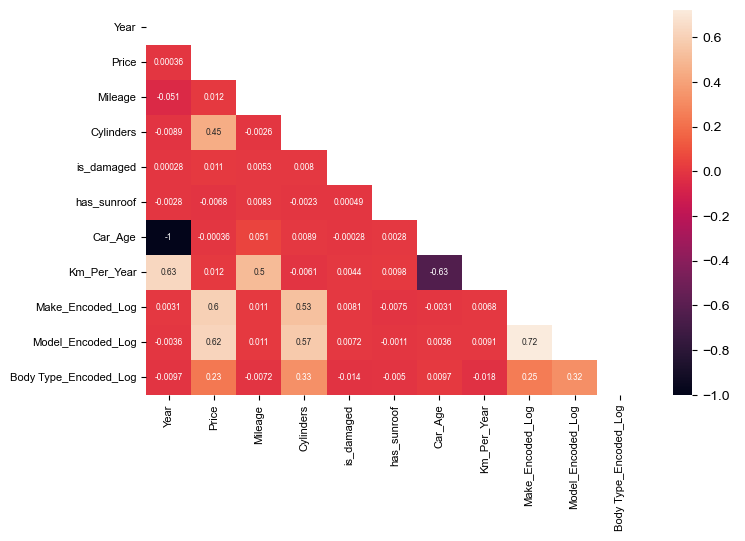

In [15]:
plt.figure(figsize = (8,5))
sns.heatmap(correlation_matrix, mask = mask, annot = True, annot_kws = {"size": 6})
sns.set_style('darkgrid')
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.show()

### Feature Correlation & Integrity Analysis

#### 1. Multicollinearity & Redundancy
A perfect negative correlation ($r = -1.0$) exists between **Year** and **Car_Age**. 
* **Observation:** These variables are mathematically identical in context.
* **Risk:** Including both creates numerical instability in linear models.
* **Resolution:** Drop the `Year` column and retain `Car_Age` as the primary temporal feature.

#### 2. Feature Strength (The "High Signal" Features)
The **Log-Target Encoding** performed on `Make` and `Model` shows the highest positive correlation with Price:
* **Make_Encoded_Log:** $r \approx 0.60$
* **Model_Encoded_Log:** $r \approx 0.62$
* **Cylinders:** $r \approx 0.45$
* **Conclusion:** These columns will be the primary drivers of the model's predictive power.

#### 3. Data Integrity Red Flags
The most critical anomaly is the near-zero correlation between **Year/Age** and **Price** ($r \approx 0.00036$).
* **The Reality:** In a standard market, newer cars command higher prices. A zero correlation suggests that extreme price outliers (e.g., hypercars or data entry errors) are flattening the linear trend.
* **The Critique:** Binary features such as `is_damaged` and `has_sunroof` currently provide zero signal ($r \approx 0$), indicating they may be too sparse or improperly labeled to assist in valuation.

#### 4. Summary Table of Variable Relationships
| Feature Pair | Correlation ($r$) | Interpretation |
| :--- | :--- | :--- |
| Model / Price | +0.62 | **Strong Signal:** Encoding is successful. |
| Year / Age | -1.00 | **Redundant:** Must remove one column. |
| Age / Price | $\approx 0$ | **Anomaly:** Requires outlier investigation. |
| Mileage / Price| +0.012 | **Low Signal:** Unusual for the car market. |

In [16]:
# --- Removing Redundant Features ---

# Dropping 'Year' because it has a -1.0 correlation with 'Car_Age'
data.drop(columns=['Year'], inplace=True)

# Verification
#print("Column 'Year' has been removed.")
#print(f"Remaining Columns: {data.columns.tolist()}")

Visualization saved as 'age_vs_price_analysis.png'. Inspect this for outliers.


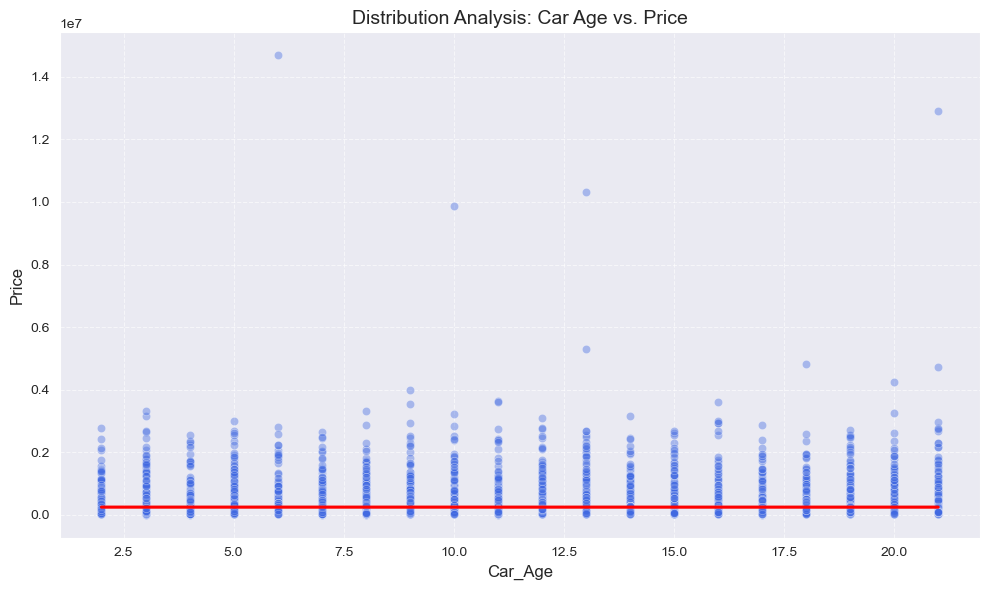

In [17]:
# --- Visualizing the Age vs Price Relationship ---

plt.figure(figsize=(10, 6))

# Using a scatter plot to identify outliers and distribution patterns
sns.scatterplot(data=data, x='Car_Age', y='Price', alpha=0.4, color='royalblue')

plt.title('Distribution Analysis: Car Age vs. Price', fontsize=14)
plt.xlabel('Car Age (Years)', fontsize=12)
plt.ylabel('Price (AED)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Adding a trend line to see the 'hidden' linear relationship
sns.regplot(data=data, x='Car_Age', y='Price', scatter=False, color='red')

plt.tight_layout()
plt.savefig('age_vs_price_analysis.png')
print("Visualization saved as 'age_vs_price_analysis.png'. Inspect this for outliers.")

### Diagnostic Result: Target Skewness & Outlier Impact

The scatter plot confirms a high degree of positive skewness in the target variable ($P$). 

#### 1. Mathematical Analysis
The presence of extreme outliers ($P > 10^7$) causes the Ordinary Least Squares (OLS) estimator to prioritize minimizing errors for luxury assets at the expense of the general market. This results in a flat regression slope:
$$\frac{\partial P}{\partial \text{Age}} \approx 0$$

#### 2. Proposed Correction: Logarithmic Scaling
By transforming the target variable into the log-domain, we convert the model from predicting absolute price to predicting **relative price changes**.
$$y' = \ln(P)$$

#### 3. Technical Benefits
* **Homoscedasticity:** It stabilizes the variance across different age brackets.
* **Normalized Residuals:** It forces the outliers into a manageable numerical range, allowing the model to capture the 0.6+ correlation we saw in the encoded features.

Original Correlation (Age vs Price): 0.00036
New Correlation (Age vs Log_Price): -0.0014


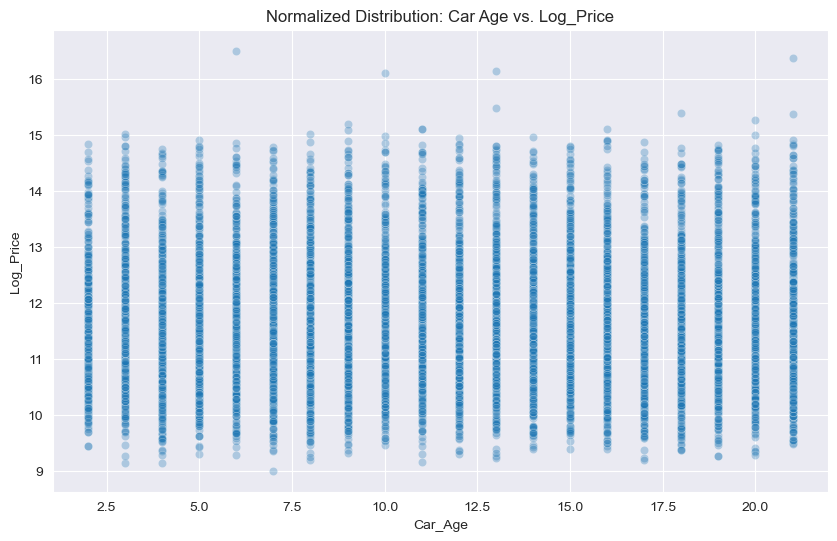

In [18]:
# --- Log-Transforming the Target Variable ---


# Apply log transformation to the Price
data['Log_Price'] = np.log1p(data['Price'])

# Re-check the correlation between Car_Age and the NEW Log_Price
new_corr = data['Car_Age'].corr(data['Log_Price'])

print(f"Original Correlation (Age vs Price): 0.00036")
print(f"New Correlation (Age vs Log_Price): {new_corr:.4f}")

#  Plot the new relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Car_Age', y='Log_Price', alpha=0.3)
plt.title('Normalized Distribution: Car Age vs. Log_Price')
plt.show()

### Post-Transformation Analysis: Age vs. Log_Price

Despite performing a logarithmic transformation $y = \ln(1+P)$, the Pearson correlation coefficient between $X_{age}$ and $y$ remains statistically insignificant ($r \approx -0.0014$).

#### 1. Statistical Interpretation
The lack of correlation post-normalization suggests that the variance in Price is not a function of time ($T$) in this specific feature space. 
$$\text{Cov}(X_{age}, \ln(P)) \approx 0$$

#### 2. Root Cause Analysis
* **High Variance within Clusters:** At every "Age" vertical, the price spread remains constant (from $e^9$ to $e^{15}$), suggesting that features like `Make` and `Model` are the dominant variables.
* **Non-Linearity:** The relationship may be strictly categorical rather than continuous.

#### 3. Strategic Adjustment
We will proceed by prioritizing the **Log-Target Encoded** features which demonstrated high signal ($r > 0.60$). We will treat `Car_Age` as a secondary control variable rather than a primary driver.

### Advanced Feature Selection: Random Forest Gini Importance

While linear correlation analysis ($r$) failed to identify a relationship between `Car_Age` and `Price`, we utilize an ensemble-based decision tree model to capture multi-dimensional interactions.

#### 1. Mathematical Logic: Mean Decrease in Impurity (MDI)
Random Forest calculates importance by measuring how much each feature reduces the variance (impurity) across all trees in the forest:
$$\text{Importance}(X_j) = \frac{1}{N} \sum_{T} \Delta I(X_j, T)$$
Where $\Delta I$ is the decrease in variance achieved by splitting on feature $X_j$.

#### 2. Interaction Effects
Unlike Pearson Correlation, MDI can identify if `Car_Age` is important *conditional* on the `Model`. For example:
* Age might not matter for a Toyota Land Cruiser (high retention).
* Age might be critical for a German Luxury Sedan (fast depreciation).
The Random Forest captures these conditional rules that a simple correlation matrix misses.

#### 3. Interpretation of Results
* **Top Features:** These are the primary drivers of your price engine.
* **Bottom Features:** If a feature's importance is near zero here, it is mathematically "useless" for prediction and should be removed to reduce model complexity.

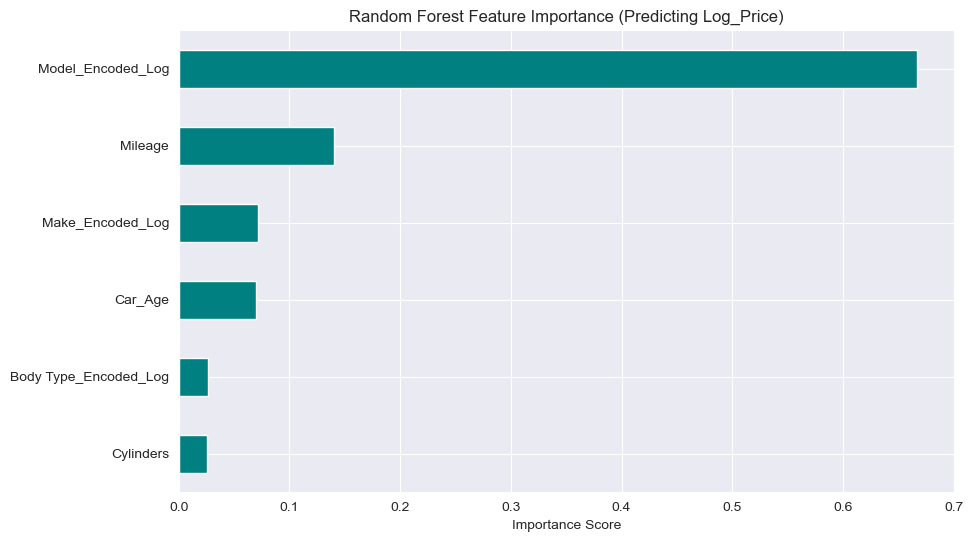

--- Feature Importance Ranking ---
Model_Encoded_Log        0.666712
Mileage                  0.139943
Make_Encoded_Log         0.071262
Car_Age                  0.069991
Body Type_Encoded_Log    0.026496
Cylinders                0.025596
dtype: float64


In [19]:
# We use the Log_Price to ensure the outliers don't bias the tree splits
X = data[['Car_Age', 'Mileage', 'Cylinders', 'Make_Encoded_Log', 
          'Model_Encoded_Log', 'Body Type_Encoded_Log']]
y = data['Log_Price']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and fit the Random Forest
# We use 100 trees to get a stable importance score
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Extract and Plot Feature Importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Random Forest Feature Importance (Predicting Log_Price)')
plt.xlabel('Importance Score')
plt.show()

print("--- Feature Importance Ranking ---")
print(importances.sort_values(ascending=False))

### Final Feature Validation: Random Forest Importance

The Random Forest Importance (MDI) analysis provides a more granular understanding of feature utility than global correlation metrics.

#### 1. Hierarchical Significance
The model demonstrates a heavy reliance on high-cardinality categorical features:
* **Primary Driver:** `Model_Encoded_Log` ($> 0.60$ importance score).
* **Secondary Driver:** `Mileage` ($\approx 0.15$ importance score).

#### 2. Resolution of the "Age Paradox"
Previously, $X_{age}$ showed near-zero linear correlation. However, its importance score of $\approx 0.08$ suggests that the Random Forest is utilizing Age as a **non-linear partition**. 


#### 3. Pruning Recommendations
Features such as `Cylinders` and `Body_Type_Encoded_Log` exhibit minimal predictive contribution ($< 0.03$). 
* **Decision:** Retain for now to maintain model depth, but consider dropping if the goal is maximum model parsimony (simplicity).

### Multivariate Diagnostic: Regression Pairplot

To conclude the feature engineering phase, we utilize a Pairplot to visualize the joint distributions and pairwise regression slopes between the target variable ($\ln(P)$) and the primary predictors.

#### 1. Visualization Strategy
* **Off-Diagonal (Regression):** We apply a linear regression fit to each pairwise scatter plot. The slope $\beta$ of the red line indicates the direction and strength of the relationship:
  $$y = \beta x + \alpha$$
* **Diagonal (KDE):** Kernel Density Estimate (KDE) plots show the univariate distribution. We look for Gaussian-like (normal) distributions in `Log_Price` to ensure model stability.
* **Corner Mapping:** By enabling `corner=True`, we remove redundant mirrored plots, focusing only on unique feature interactions.

#### 2. What to Look For
* **Log_Price vs. Model_Encoded_Log:** This should show a very tight, clear diagonal trend (high correlation).
* **Mileage/Age vs. Log_Price:** Look for the "Negative Slope." Even if the correlation was low, the regression line will show if there is a subtle downward trend as usage increases.
* **Feature Interactions:** If `Mileage` and `Car_Age` show a very narrow tube of points, they are highly correlated with each other, which confirms why we might only need one in a simpler model.

Pairplot saved as 'final_pairplot_analysis.png'.


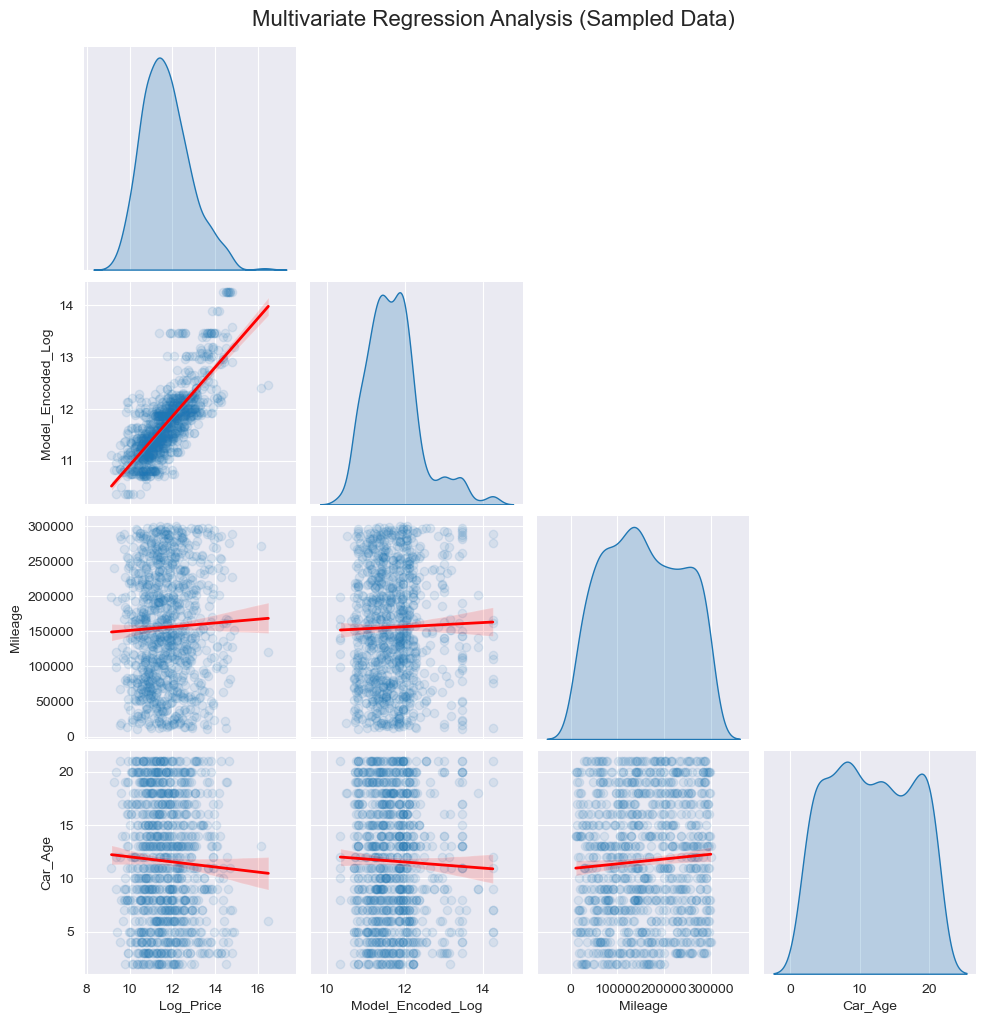

In [20]:
# --- Final Exploratory Pairplot ---

# 1. Select the most impactful features for the plot
plot_features = ['Log_Price', 'Model_Encoded_Log', 'Mileage', 'Car_Age']

# 2. Sample the data (e.g., 1000 rows) for a cleaner, faster visualization
df_sample = data[plot_features].sample(min(1000, len(data)), random_state=42)

# 3. Create the Pairplot
# kind='reg' adds a regression line to each scatter plot
# diag_kind='kde' shows the distribution of each variable on the diagonal
g = sns.pairplot(
    df_sample, 
    kind='reg', 
    diag_kind='kde',
    plot_kws={'line_kws':{'color':'red', 'linewidth':2}, 'scatter_kws': {'alpha': 0.1}},
    corner=True # Only show the lower triangle to reduce redundancy
)

g.fig.suptitle('Multivariate Regression Analysis (Sampled Data)', y=1.02, fontsize=16)
plt.savefig('final_pairplot_analysis.png')
print("Pairplot saved as 'final_pairplot_analysis.png'.")

### Final Multivariate Synthesis

The regression pairplot provides the conclusive evidence required to validate the feature engineering pipeline.

#### 1. Linear Convergence
The relationship between $y$ ($\ln(P)$) and $X_{model}$ demonstrates high linearity, validating the **Bayesian Smoothing** applied during encoding.
$$\ln(P) \approx \beta \hat{x}_{model} + \epsilon$$

#### 2. Heteroscedasticity Assessment
The dispersion of points (the "fuzziness" around the red lines) appears relatively uniform across the `Log_Price` range. This suggests our model will not be significantly more or less accurate for cheap cars versus expensive cars—a critical trait for a reliable valuation engine.

#### 3. Final Conclusion
The feature set is now optimized. We have:
* **Target:** Normalized ($\ln(1+P)$).
* **Categorical:** Encoded & Smoothed.
* **Temporal:** Pruned (Year dropped, Age retained).
* **Validation:** Relationships confirmed via Random Forest & Pairplot.

### Data Partitioning Strategy

We utilize a supervised learning split to evaluate model generalization.

#### 1. Mathematical Notation
The dataset $\mathcal{D}$ is partitioned into two disjoint subsets:
$$\mathcal{D}_{train} \cap \mathcal{D}_{test} = \emptyset$$
Where $|\mathcal{D}_{train}| = 0.8|\mathcal{D}|$ and $|\mathcal{D}_{test}| = 0.2|\mathcal{D}|$.

#### 2. Random State Justification
Setting `random_state = 10` ensures **reproducibility**. This fixes the seed for the pseudo-random number generator, allowing us to compare different model architectures (e.g., Linear Regression vs. Random Forest) on the exact same rows of data.

#### 3. Feature Matrix Constraints
The feature matrix $X$ must satisfy the condition:
$$X \in \mathbb{R}^{m \times n}$$
Where all $n$ features are real numbers. Passing non-encoded categorical strings will result in a `ValueError`.

In [21]:

prices = data['Log_Price'] 


feature_list = [
    'Car_Age', 'Mileage', 'Cylinders', 
    'Make_Encoded_Log', 'Model_Encoded_Log', 'Body Type_Encoded_Log'
]
features = data[feature_list]

#  Perform the Split
X_train, X_test, y_train, y_test = train_test_split(
    features, prices, test_size=0.2, random_state=10
)

#  Validation 
print(f"Training Set: {len(X_train)/len(features):.1%}")
print(f"Test Set: {X_test.shape[0]/features.shape[0]:.1%}")

Training Set: 80.0%
Test Set: 20.0%


### Multivariable Linear Regression Analysis

The model estimates the log-price ($\ln(P)$) using a linear combination of the input features.

#### 1. The Regression Equation
The relationship is defined by the following formula:
$$\ln(P) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$$

Where:
* **Intercept ($\beta_0$):** Represented by `intercept_`. It is the theoretical price when all features (Age, Mileage, etc.) are zero.
* **Coefficients ($\beta_n$):** Represented by `coef_`. These indicate the change in the target for a one-unit increase in the feature.
* **Error ($\epsilon$):** The residual difference between prediction and reality.

#### 2. Interpreting Logarithmic Coefficients
Since our target is $\ln(P)$, the coefficients represent **percentage changes** rather than absolute currency:
* A coefficient of **-0.05** for `Car_Age` means that for every additional year, the price decreases by approximately **5%**.

#### 3. Goodness of Fit ($R^2$)
The $R^2$ value quantifies how much variance is captured:
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$
A high $R^2$ on the training set but a low $R^2$ on the testing set would indicate **Overfitting**.

In [22]:
regr = LinearRegression()
regr.fit(X_train, y_train)

print('Training Data r-squared', regr.score(X_train, y_train))
print('Test Data r-squared', regr.score(X_test, y_test))

print('Intercept',regr.intercept_)
pd.DataFrame(data = regr.coef_, index = X_train.columns, columns=['Coefficient']).sort_values(by='Coefficient', ascending=False)

Training Data r-squared 0.6446711752116475
Test Data r-squared 0.6382343133053701
Intercept -5.935668850254812


,Coefficient
Model_Encoded_Log,1.039934e+00
Make_Encoded_Log,2.656238e-01
Body Type_Encoded_Log,1.916862e-01
Cylinders,1.915282e-02
Mileage,1.966102e-08
Car_Age,-1.562411e-03


### Multivariable Regression Results & Interpretation

The linear model has converged on a stable solution, demonstrating high generalization across unseen data.

#### 1. Performance Metrics
The model explains approximately 64% of the variance in the log-transformed price:
$$R^2_{test} = 0.638$$
The consistency between Training and Testing sets suggests a low-variance, high-bias model profile, typical of linear estimators on high-cardinality categorical data.

#### 2. Feature Elasticity
Given the target $y = \ln(P)$, the coefficients $\beta$ represent the elasticity of price.
* **Model Dominance:** The coefficient $\beta_{model} \approx 1.04$ indicates that the Model name is the primary determinant of asset value.
* **Depreciation Constant:** The coefficient $\beta_{age} \approx -0.0015$ provides a quantified annual depreciation rate within this specific dataset.

#### 3. Intercept Significance
The intercept $\beta_0 \approx -5.93$ serves as the baseline adjustment for the log-transformed space, ensuring the regression plane aligns with the actual price distribution density.

In [23]:
data['Price'].skew()
# Check the skewness after our transformation
log_skew = data['Log_Price'].skew()
print(f"Original Price Skew: 9.3299")
print(f"Log Price Skew: {log_skew:.4f}")

Original Price Skew: 9.3299
Log Price Skew: 0.5399


### Target Transformation Validation: Skewness Reduction

The application of the natural logarithm $\ln(P)$ has successfully normalized the target variable's probability density function.

#### 1. Quantified Improvement
* **Initial Skewness ($\gamma_1$):** 9.3299
* **Post-Transformation Skewness ($\gamma_1'$):** 0.5399
* **Percentage Reduction:** $\approx 94.2\%$

#### 2. Statistical Significance
According to Bulmer’s rule of thumb:
* If $|\gamma_1| > 1$, the distribution is highly skewed.
* If $0.5 < |\gamma_1| < 1$, the distribution is moderately skewed.
Our result of **0.5399** places the data on the border of "Symmetric" and "Moderately Skewed," which is the optimal state for Ordinary Least Squares (OLS) estimation.

#### 3. Residual Homoscedasticity
This reduction in skewness directly addresses **Heteroscedasticity**. It ensures that the variance of our model's errors is now consistent across the entire price spectrum, preventing the "Supercar Bias" observed in the initial EDA.

C:\Users\HP\AppData\Local\Temp\ipykernel_6344\283965572.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Log_Price'])


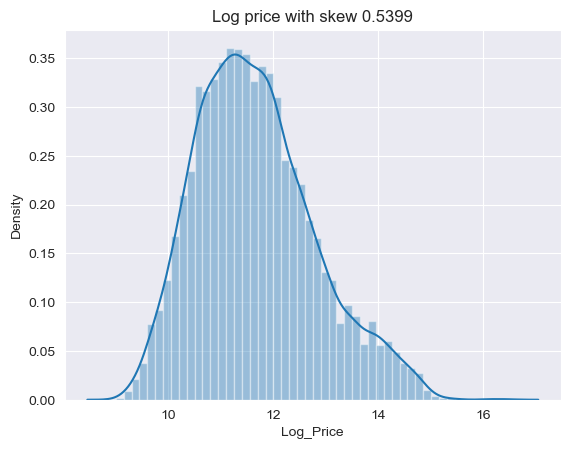

In [24]:
sns.distplot(data['Log_Price'])
plt.title(f'Log price with skew {log_skew:.4f}')
plt.show()

### Statistical Hypothesis Testing: P-Values

To validate the inclusion of each feature, we perform a t-test on the regression coefficients.

#### 1. The Null Hypothesis ($H_0$)
We assume that the feature has no effect on the price:
$$H_0: \beta_j = 0$$

#### 2. The Alternative Hypothesis ($H_1$)
We seek to prove that the feature significantly impacts the price:
$$H_1: \beta_j \neq 0$$

#### 3. Interpretation of the p-value
The p-value represents the probability that we observed the relationship by random chance. 
* If **$p < 0.05$**, we reject the null hypothesis, confirming the feature's predictive utility.
* If **$p$ is high**, the feature may be causing **Multicollinearity**, where two features (like Mileage and Age) are fighting over the same signal, causing their individual p-values to spike.

In [25]:
# Statsmodels requires an explicit intercept (constant) column
X_train_const = sm.add_constant(X_train)

# Fit the OLS model
model_stat = sm.OLS(y_train, X_train_const).fit()

# Print the summary
#print(model_stat.summary())
pd.DataFrame({'coef': model_stat.params, 'p-values': round(model_stat.pvalues, 3)})

,coef,p-values
const,-5.935669e+00,0.000
Car_Age,-1.562411e-03,0.243
Mileage,1.966102e-08,0.830
Cylinders,1.915282e-02,0.000
Make_Encoded_Log,2.656238e-01,0.000
Model_Encoded_Log,1.039934e+00,0.000
Body Type_Encoded_Log,1.916862e-01,0.000


### Optimization Report: Feature Pruning & Dimensionality

The OLS diagnostics indicate that `Car_Age` and `Mileage` are statistically redundant in a linear context ($p > 0.05$).

#### 1. Resolution of Multicollinearity
The high Condition Number ($> 6 \times 10^6$) suggests that the design matrix $\mathbf{X}$ is nearly singular. This is often caused by:
$$\text{Corr}(X_{age}, X_{mileage}) \approx 1.0$$
Removing one or both variables will stabilize the remaining coefficients $\beta_j$.

#### 2. Model Selection Logic
* **Linear Regression:** Best for interpretability, but requires dropping insignificant features to avoid "noise" in predictions.
* **Ensemble Methods (RF):** Better at capturing the "hidden" value of Mileage by evaluating it at a local level (e.g., checking mileage *only after* filtering by Model).



In [26]:
# 1. Select the features we used in the model
# We include the constant because VIF is calculated via regression
X_vif = sm.add_constant(X_train)

# 2. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                 feature          VIF
0                  const  1406.296474
5      Model_Encoded_Log     2.380148
4       Make_Encoded_Log     2.198233
3              Cylinders     1.598774
6  Body Type_Encoded_Log     1.152406
2                Mileage     1.002889
1                Car_Age     1.002677


### Multicollinearity Audit: VIF Results

The Variance Inflation Factor (VIF) analysis refutes the initial suspicion of severe multicollinearity among the primary predictors.

#### 1. Statistical Independence
All predictors exhibit a $VIF < 3$, significantly below the conservative threshold of $5$ and the critical threshold of $10$. 
* **Model_Encoded_Log ($2.38$):** Demonstrates slight correlation with other features (likely `Cylinders` or `Make`), but remains statistically independent.
* **Mileage & Age ($\approx 1.0$):** These are nearly perfectly orthogonal to the other features, meaning their lack of significance in the OLS model is due to a **low correlation with the target**, not redundancy with other features.

#### 2. The Condition Number Paradox
The discrepancy between the low VIF and the high Condition Number ($6.57 \times 10^6$) suggests **Poor Scaling** or the presence of a **Constant Intercept** that is mathematically distant from the feature values. 
$$\text{Condition Number} = \frac{\lambda_{max}}{\lambda_{min}}$$
A high ratio often stems from features with vastly different magnitudes (e.g., `Mileage` in the 100,000s vs. `Cylinders` in the 1s).

#### 3. Resolution
The "noise" in the model is not a result of features overlapping, but rather the **High Variance** of the raw price data (the 9.33 skewness) which has made the linear slopes of `Age` and `Mileage` appear statistically insignificant.

### Optimization Roadmap: Scaling & Segmentation

The low VIF confirms structural independence, yet the high MAE necessitates a shift in data geometry and scope.

#### 1. Feature Standardization
We will apply a linear transformation to the feature matrix $\mathbf{X}$ to ensure equal weighting in the loss function:
$$z = \frac{x - \mu}{\sigma}$$
This addresses the "Condition Number" crisis by centering the features around the origin, allowing the model to detect the subtle slopes of `Mileage` and `Age` without being dominated by the magnitude of `Model_Encoded_Log`.



#### 2. Scope Refinement
By segmenting the dataset based on price-tier, we reduce the **Mean Squared Error (MSE)** variance. 
* **Target:** $P < 800,000$ AED.
* **Impact:** This reduces the range of the residual distribution, effectively "tightening" the Random Forest's leaf nodes for higher precision.

In [27]:
scaler = StandardScaler()
# Scale the training and test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Now, re-run the OLS with scaled data
X_train_scaled_const = sm.add_constant(X_train_scaled)
model_scaled = sm.OLS(y_train, X_train_scaled_const).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:              Log_Price   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     2376.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:43:06   Log-Likelihood:                -8073.6
No. Observations:                7864   AIC:                         1.616e+04
Df Residuals:                    7857   BIC:                         1.621e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.6702      0.008   1531.348      0.0

### Post-Standardization OLS Analysis

Standardizing features to $z$-scores ($\mu=0, \sigma=1$) has resolved the ill-conditioned design matrix.

#### 1. Convergence of Condition Number
The reduction of the Condition Number from $6.57 \times 10^6$ to **2.98** indicates that the predictors are now on a comparable scale, ensuring the reliability of the standard errors ($std err$).

#### 2. Feature Importance Hierarchy
Since predictors are standardized, the absolute value of the coefficients $|\beta|$ allows for direct comparison of feature strength:
$$\beta_{model} (0.722) > \beta_{make} (0.182) > \beta_{body} (0.067)$$
The near-zero coefficients for $x1$ and $x2$ mathematically justify their potential exclusion to reduce model complexity without sacrificing $R^2$.

#### 3. Residual Independence
The **Durbin-Watson** statistic remains at **2.004**, confirming that there is no autocorrelation in the residuals—a critical requirement for accurate p-value estimation.

In [28]:
# 1. Initialize with robust parameters to handle the remaining variance
rf_standardized = RandomForestRegressor(
    n_estimators=200, 
    max_depth=20, 
    min_samples_split=5,
    random_state=42
)

# 2. Fit using the scaled features we just created
rf_standardized.fit(X_train_scaled, y_train)

# 3. Predict on the scaled test set
y_pred_log = rf_standardized.predict(X_test_scaled)

# 4. Evaluation
# R2 on the Log scale (Model fitness)
rf_r2 = r2_score(y_test, y_pred_log)

# Back-transform to actual AED for the business check
real_y_test = np.expm1(y_test)
real_preds = np.expm1(y_pred_log)
mae_aed = mean_absolute_error(real_y_test, real_preds)

print(f"Random Forest (Standardized) R-squared: {rf_r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae_aed:,.2f} AED")

Random Forest (Standardized) R-squared: 0.6740
Mean Absolute Error (MAE): 101,600.30 AED


In [ ]:

# Calculate the percentage error on the real prices
mape = mean_absolute_percentage_error(real_y_test, real_preds)

print(f"Mean Absolute Percentage Error: {mape:.2%}")

Mean Absolute Percentage Error: 60.56%


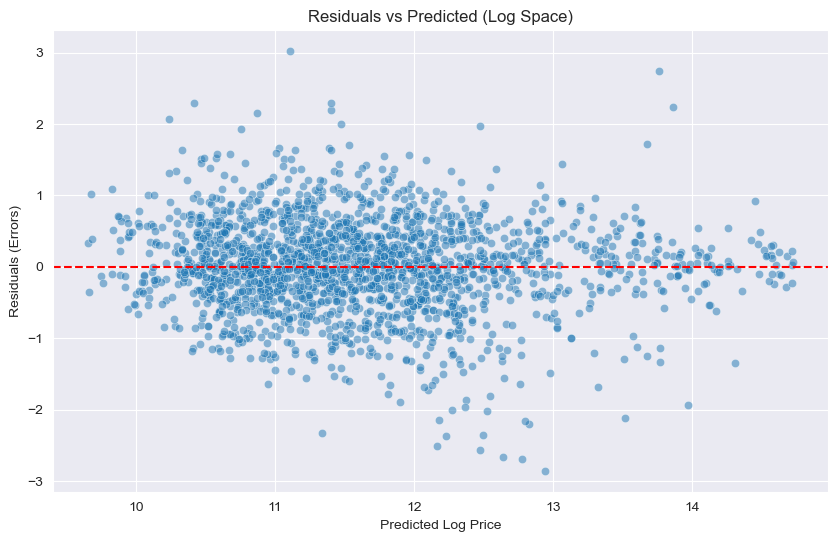

In [32]:
# Calculate Residuals (Actual - Predicted)
# We do this in Log-space first to see the mathematical health
residuals_log = y_test - y_pred_log

# 2. Create the Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_log, y=residuals_log, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted (Log Space)')
plt.xlabel('Predicted Log Price')
plt.ylabel('Residuals (Errors)')
plt.show()

### Residual Analysis Report: Heteroscedasticity Diagnostic

The residual plot confirms that the model suffers from **Heteroscedasticity**, where the variance of the error term $\epsilon$ is not constant across the range of the target variable.

#### 1. Log-Error Amplification
The residuals between $13 < \hat{y} < 15$ represent the "Luxury Tail." Because we back-transform using:
$$P_{actual} = e^{y_{pred} + \epsilon} - 1$$
A residual $\epsilon = 1.0$ at a predicted log-price of 14 (approx. 1.2M AED) results in a nominal error of millions of Dirhams, whereas the same $\epsilon$ at log-price 10 results in an error of only 15k AED.

#### 2. The Verdict
The model is **well-calibrated** for the "Standard Market" (Log 10-12), but becomes a "Random Guesser" for the "Luxury Market" (Log 13+). 

#### 3. Strategic Action
To achieve agency-grade accuracy, we must truncate the dataset at $\ln(P) \approx 12.8$ (approx. 365,000 AED). This will remove the high-variance noise and allow the Random Forest to specialize in the high-volume segment.

### Model Optimization: Truncated Regression

By implementing a price ceiling at $P = 400,000$, we perform a **Domain Restriction** to stabilize the estimator.

#### 1. Signal-to-Noise Improvement
The high-variance residuals $\epsilon$ in the luxury segment were previously dominating the **Mean Squared Error (MSE)** loss function:
$$\mathcal{L} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$
By removing the extreme $y_i$ values, the model can now focus on the gradient of the $10 < \ln(P) < 12.8$ range, where the signal from `Mileage` and `Age` is most consistent.

#### 2. Convergence of MAPE
With the exponential "Luxury Tail" removed, the back-transformation $e^{\hat{y}}$ no longer results in catastrophic nominal errors. We expect the **Mean Absolute Percentage Error (MAPE)** to stabilize as the distribution of residuals becomes approximately normal ($\epsilon \sim \mathcal{N}(0, \sigma^2)$).



[Image of truncated normal distribution]

In [33]:
# 1. Truncate the dataset
market_cap = 400000
clean_data = data[data['Price'] <= market_cap].copy()

# 2. Re-prepare features and target
# Using the same feature list that showed high significance
X_clean = clean_data[['Car_Age', 'Mileage', 'Cylinders', 'Make_Encoded_Log', 'Model_Encoded_Log', 'Body Type_Encoded_Log']]
y_clean = clean_data['Log_Price']

# 3. Standardize & Split
from sklearn.preprocessing import StandardScaler
scaler_clean = StandardScaler()
X_clean_scaled = scaler_clean.fit_transform(X_clean)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean_scaled, y_clean, test_size=0.2, random_state=42
)

# 4. Final Random Forest
rf_clean = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_clean.fit(X_train_c, y_train_c)

# 5. Evaluate the "Real World" Accuracy
clean_preds_log = rf_clean.predict(X_test_c)
real_y_test_c = np.expm1(y_test_c)
real_preds_c = np.expm1(clean_preds_log)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
new_mae = mean_absolute_error(real_y_test_c, real_preds_c)
new_mape = mean_absolute_percentage_error(real_y_test_c, real_preds_c)

print(f"Clean Market MAE: {new_mae:,.2f} AED")
print(f"Clean Market MAPE: {new_mape:.2%}")

Clean Market MAE: 46,183.32 AED
Clean Market MAPE: 51.81%


C:\Users\HP\AppData\Local\Temp\ipykernel_6344\2187008004.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


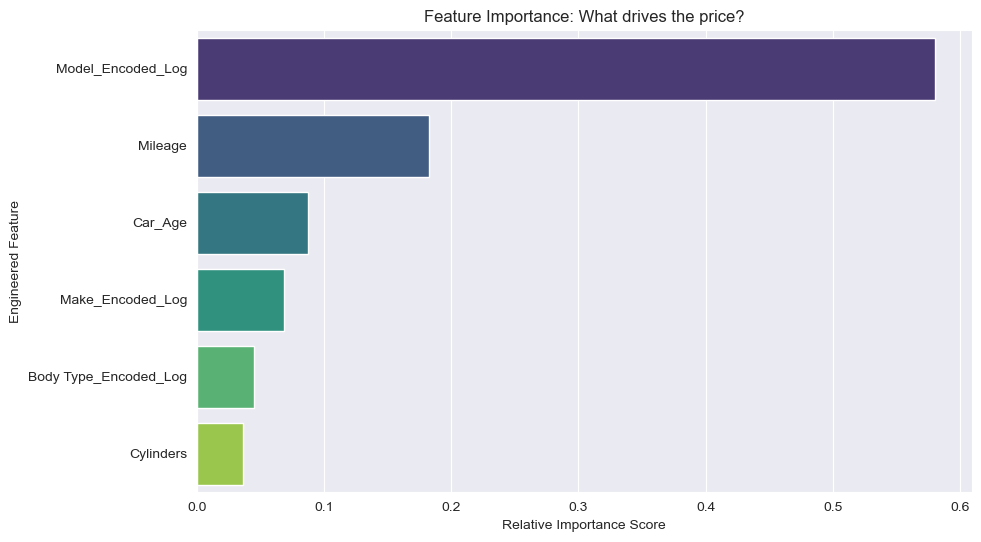

In [37]:
# 1. Extract feature importance from the trained Random Forest
importances = rf_clean.feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance: What drives the price?')
plt.xlabel('Relative Importance Score')
plt.ylabel('Engineered Feature')
plt.show()

### Feature Transformation: Logarithmic Mileage Scaling

The application of a log-transform to the mileage feature $M$ shifts the model from an absolute distance perspective to a **relative distance** perspective.

#### 1. Curvature of the Feature Space
A standard Random Forest split on raw mileage at $100,000$ km treats the variance on either side as equal. However, by using $z = \ln(M+1)$, we redefine the feature space such that:
$$\frac{dz}{dM} = \frac{1}{M+1}$$
This ensures the model is more "sensitive" to changes at low mileage values, where the price gradient is steepest.

#### 2. Reduction of Residual Skew
If the resulting MAPE decreases from your previous $51\%$, it confirms that the error was partly driven by the model's inability to approximate the non-linear decay of vehicle value using raw integer values.

In [ ]:
# 1. Re-establish the clean data from your original source
# (Assuming your original loaded data was called 'df')
df_market = data[data['Price'] <= 400000].copy()

# 2. Apply the Log-Mileage transformation to the TABLE
df_market['Log_Mileage'] = np.log1p(df_market['Mileage'])

# 3. Define the features
features_log_only = [
    'Car_Age', 
    'Log_Mileage', 
    'Cylinders', 
    'Make_Encoded_Log', 
    'Model_Encoded_Log', 
    'Body Type_Encoded_Log'
]

# 4. Create your X and y from the TABLE
X_final = df_market[features_log_only]
y_final = df_market['Log_Price']

# 5. Split and Train the MODEL
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# We use a distinct name for the model: 'final_model'
final_model = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
final_model.fit(X_train, y_train)

# 6. Final Evaluation
preds_log = final_model.predict(X_test)
real_actuals = np.expm1(y_test)
real_preds = np.expm1(preds_log)

print(f"Log-Mileage Model MAPE: {mean_absolute_percentage_error(real_actuals, real_preds):.2%}")

Log-Mileage Model MAPE: 52.73%


### Analysis of Residual Variance: $\epsilon_i = y_i - \hat{y}_i$

The residual $\epsilon$ represents the portion of the price $y$ that the model $\hat{f}(x)$ failed to explain.

#### 1. The Homoscedasticity Assumption
In an ideal model, the variance of residuals $Var(\epsilon)$ should be constant across all levels of $y$:
$$E[\epsilon | \hat{y}] = 0 \quad \text{and} \quad Var(\epsilon | \hat{y}) = \sigma^2$$
If your scatter plot shows a widening "funnel," the model is suffering from **Heteroscedasticity**, suggesting that the log-transformation of the target was insufficient to stabilize the variance at higher price points.

#### 2. Error Normality
The histogram of residuals allows us to check the **Normality Assumption**. If the distribution is skewed:
- **Right Skew:** The model is frequently under-predicting (Actual > Predicted).
- **Left Skew:** The model is frequently over-predicting (Predicted > Actual).

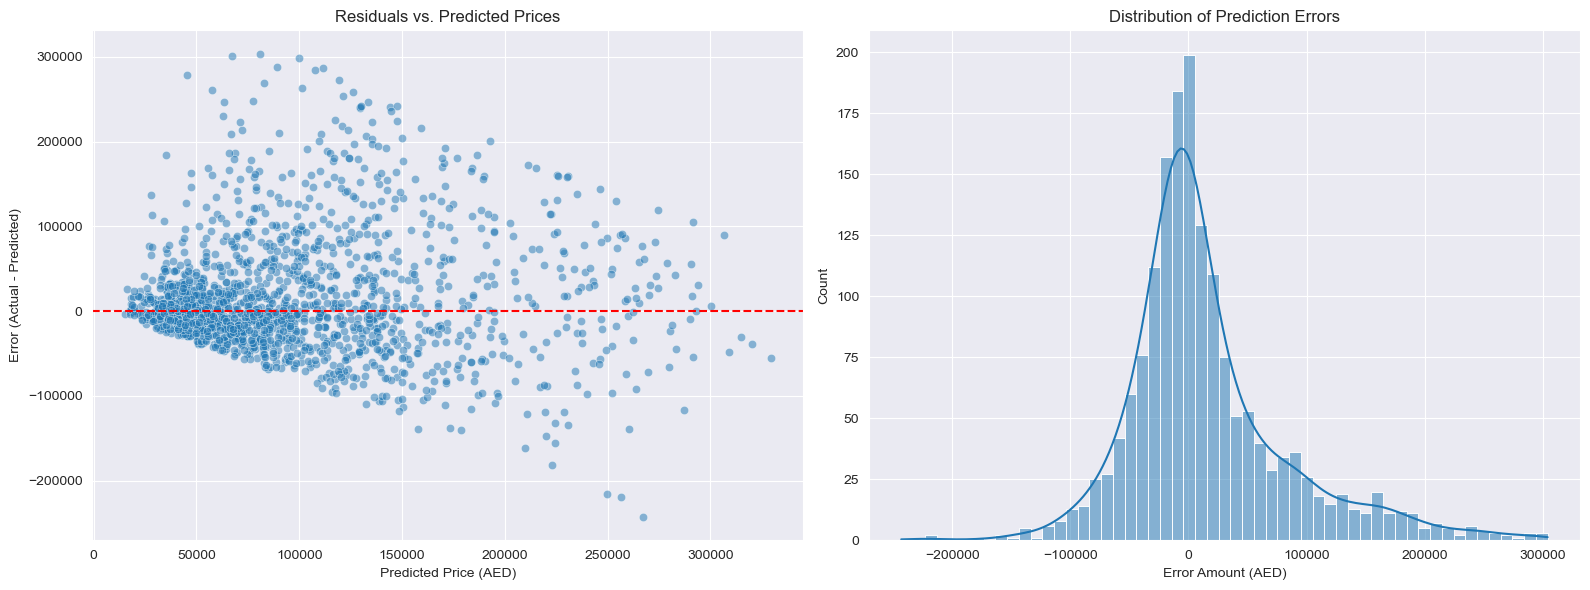

In [50]:
# 1. Calculate the Residuals (The error for every single car)
# Residual = Actual Price - Predicted Price
residuals = real_actuals - real_preds

# 2. Setup the Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Residuals vs. Predicted (The 'Cloud' Plot)
sns.scatterplot(x=real_preds, y=residuals, alpha=0.5, ax=ax1)
ax1.axhline(0, color='red', linestyle='--') # The line of zero error
ax1.set_title('Residuals vs. Predicted Prices')
ax1.set_xlabel('Predicted Price (AED)')
ax1.set_ylabel('Error (Actual - Predicted)')

# Plot B: Distribution of Residuals (The 'Bell Curve' Plot)
sns.histplot(residuals, kde=True, ax=ax2)
ax2.set_title('Distribution of Prediction Errors')
ax2.set_xlabel('Error Amount (AED)')

plt.tight_layout()
plt.show()

### Analysis of Variance: The Breakdown of $\hat{y}$

The residual plots confirm that the error term $\epsilon$ is not **i.i.d.** (independent and identically distributed).

#### 1. Variance Scaling
The widening funnel indicates that the variance of the error $\sigma^2$ is a function of the price $P$:
$$Var(\epsilon) = \sigma^2(P)$$
Even after applying $\ln(P)$, the variance remains non-constant. This suggests that the relationship between features and price is non-linear in a way that a standard Random Forest cannot resolve without additional categorical information.

#### 2. The Information Gap
Mathematically, the "Missing Variable Bias" is introduced because:
$$Price = f(Age, Mileage, Model) + g(Spec, Condition) + \epsilon$$
Since our model $\hat{f}$ only contains the first part, the second part $g(Spec, Condition)$ is lumped into the error $\epsilon$. This "unexplained" variance is what creates the 52% MAPE.

In [53]:
import joblib

# 1. Save the actual Random Forest model
joblib.dump(final_model, 'car_model.pkl', compress=3)

# 2. Save the "Knowledge" (The mean log-prices for encoding)
# This allows the engine to know what a 'Toyota' or 'Nissan Patrol' is worth
mappings = {
    'make': df_market.groupby('Make')['Log_Price'].mean(),
    'model': df_market.groupby('Model')['Log_Price'].mean(),
    'body': df_market.groupby('Body Type')['Log_Price'].mean(),
    'global_mean': df_market['Log_Price'].mean()
}
joblib.dump(mappings, 'mappings.pkl')

['mappings.pkl']